In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

In [3]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [4]:
print("Fund Master :", fund_master.shape)
print("NAV History :", nav_history.shape)
print("Transactions :", transactions.shape)
print("Holdings :", holdings.shape)

Fund Master : (40, 15)
NAV History : (46000, 3)
Transactions : (32778, 13)
Holdings : (322, 8)


In [5]:
print("Fund Master")
print(fund_master.columns)

print("\nNAV History")
print(nav_history.columns)

print("\nTransactions")
print(transactions.columns)

print("\nHoldings")
print(holdings.columns)

Fund Master
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

NAV History
Index(['amfi_code', 'date', 'nav'], dtype='object')

Transactions
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

Holdings
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [6]:
nav_history = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [7]:
nav_history.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [8]:
nav_history.shape

(46000, 4)

In [9]:
nav_history = nav_history.sort_values(
    ["scheme_name", "date"]
)

nav_history["daily_return"] = (
    nav_history
    .groupby("scheme_name")["nav"]
    .pct_change()
)

In [10]:
nav_history.head(10)

,amfi_code,date,nav,scheme_name,daily_return
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314
3455,101206,2022-01-10,307.5591,ABSL Frontline Equity Fund - Regular - Growth,0.011548
3456,101206,2022-01-11,309.4372,ABSL Frontline Equity Fund - Regular - Growth,0.006106
3457,101206,2022-01-12,313.2022,ABSL Frontline Equity Fund - Regular - Growth,0.012167
3458,101206,2022-01-13,310.7396,ABSL Frontline Equity Fund - Regular - Growth,-0.007863
3459,101206,2022-01-14,308.9641,ABSL Frontline Equity Fund - Regular - Growth,-0.005714


In [11]:
print(nav_history["daily_return"].describe())

print("\nMissing Values:", nav_history["daily_return"].isna().sum())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Missing Values: 40


In [12]:
# Historical Value at Risk (95%)

var_report = (
    nav_history
    .groupby("scheme_name")["daily_return"]
    .quantile(0.05)
    .reset_index()
)

var_report.columns = [
    "scheme_name",
    "VaR_95"
]

var_report.head()

,scheme_name,VaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282
1,ABSL Liquid Fund - Regular - Growth,-0.000269
2,ABSL Small Cap Fund - Regular - Growth,-0.026021
3,Axis Bluechip Fund - Direct - Growth,-0.014226
4,Axis Bluechip Fund - Regular - Growth,-0.013750


In [13]:
cvar_list = []

for scheme in nav_history["scheme_name"].unique():

    temp = nav_history[
        nav_history["scheme_name"] == scheme
    ]

    var_threshold = temp["daily_return"].quantile(0.05)

    cvar = temp[
        temp["daily_return"] <= var_threshold
    ]["daily_return"].mean()

    cvar_list.append(
        [scheme, cvar]
    )

cvar_report = pd.DataFrame(
    cvar_list,
    columns=[
        "scheme_name",
        "CVaR_95"
    ]
)

cvar_report.head()

,scheme_name,CVaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.017439
1,ABSL Liquid Fund - Regular - Growth,-0.000422
2,ABSL Small Cap Fund - Regular - Growth,-0.032459
3,Axis Bluechip Fund - Direct - Growth,-0.017487
4,Axis Bluechip Fund - Regular - Growth,-0.017328


In [14]:
var_report = var_report.merge(
    cvar_report,
    on="scheme_name"
)

var_report.head()

,scheme_name,VaR_95,CVaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
1,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
3,Axis Bluechip Fund - Direct - Growth,-0.014226,-0.017487
4,Axis Bluechip Fund - Regular - Growth,-0.013750,-0.017328


In [15]:
var_report = var_report.sort_values(
    by="VaR_95"
)

var_report.head(10)

,scheme_name,VaR_95,CVaR_95
35,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
6,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
31,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
36,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
8,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
38,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
18,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
5,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


In [16]:
var_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [17]:
print("Total Funds :", len(var_report))

print("\nLowest VaR (Highest Risk)")
print(var_report.head(5))

print("\nHighest VaR (Lowest Risk)")
print(var_report.tail(5))

Total Funds : 40

Lowest VaR (Highest Risk)
                                       scheme_name    VaR_95   CVaR_95
35       SBI Small Cap Fund - Direct Plan - Growth -0.026859 -0.032384
6           Axis Small Cap Fund - Regular - Growth -0.026188 -0.031667
2           ABSL Small Cap Fund - Regular - Growth -0.026021 -0.032459
31  Nippon India Small Cap Fund - Regular - Growth -0.025438 -0.032304
36      SBI Small Cap Fund - Regular Plan - Growth -0.024507 -0.030595

Highest VaR (Lowest Risk)
                                          scheme_name    VaR_95   CVaR_95
28  Nippon India Gilt Securities Fund - Regular - ... -0.003804 -0.004919
12       HDFC Short Term Debt Fund - Regular - Growth -0.003793 -0.004994
23               Kotak Liquid Fund - Regular - Growth -0.000285 -0.000411
1                 ABSL Liquid Fund - Regular - Growth -0.000269 -0.000422
17           ICICI Pru Liquid Fund - Regular - Growth -0.000222 -0.000373


In [18]:
top5_funds = [
    "ICICI Pru Midcap Fund - Regular - Growth",
    "SBI Small Cap Fund - Regular Plan - Growth",
    "DSP Small Cap Fund - Regular - Growth",
    "Mirae Asset Tax Saver Fund - Regular - Growth",
    "Mirae Asset Large Cap Fund - Regular - Growth"
]

top5_funds

['ICICI Pru Midcap Fund - Regular - Growth',
 'SBI Small Cap Fund - Regular Plan - Growth',
 'DSP Small Cap Fund - Regular - Growth',
 'Mirae Asset Tax Saver Fund - Regular - Growth',
 'Mirae Asset Large Cap Fund - Regular - Growth']

In [19]:
rolling_data = nav_history[
    nav_history["scheme_name"].isin(top5_funds)
].copy()

rolling_data.shape

(5750, 5)

In [20]:
rolling_data["Rolling Sharpe"] = (

    rolling_data
    .groupby("scheme_name")["daily_return"]

    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )

)

In [21]:
rolling_data.head(100)

,amfi_code,date,nav,scheme_name,daily_return,Rolling Sharpe
44850,149324,2022-01-03,81.6814,DSP Small Cap Fund - Regular - Growth,NaN,NaN
44851,149324,2022-01-04,80.8239,DSP Small Cap Fund - Regular - Growth,-0.010498,NaN
44852,149324,2022-01-05,80.6143,DSP Small Cap Fund - Regular - Growth,-0.002593,NaN
44853,149324,2022-01-06,79.9386,DSP Small Cap Fund - Regular - Growth,-0.008382,NaN
44854,149324,2022-01-07,80.8723,DSP Small Cap Fund - Regular - Growth,0.011680,NaN
...,...,...,...,...,...,...
44945,149324,2022-05-16,85.2753,DSP Small Cap Fund - Regular - Growth,0.017508,0.688609
44946,149324,2022-05-17,84.8414,DSP Small Cap Fund - Regular - Growth,-0.005088,0.661369
44947,149324,2022-05-18,84.9218,DSP Small Cap Fund - Regular - Growth,0.000948,0.674504
44948,149324,2022-05-19,83.9751,DSP Small Cap Fund - Regular - Growth,-0.011148,0.353436


In [22]:
rolling_data.iloc[85:100]

,amfi_code,date,nav,scheme_name,daily_return,Rolling Sharpe
44935,149324,2022-05-02,76.8819,DSP Small Cap Fund - Regular - Growth,0.008520,NaN
44936,149324,2022-05-03,78.4759,DSP Small Cap Fund - Regular - Growth,0.020733,NaN
44937,149324,2022-05-04,77.9278,DSP Small Cap Fund - Regular - Growth,-0.006984,NaN
44938,149324,2022-05-05,80.3220,DSP Small Cap Fund - Regular - Growth,0.030723,NaN
44939,149324,2022-05-06,80.8703,DSP Small Cap Fund - Regular - Growth,0.006826,NaN
44940,149324,2022-05-09,81.2707,DSP Small Cap Fund - Regular - Growth,0.004951,0.071434
44941,149324,2022-05-10,82.1851,DSP Small Cap Fund - Regular - Growth,0.011251,0.309718
44942,149324,2022-05-11,83.5299,DSP Small Cap Fund - Regular - Growth,0.016363,0.514685
44943,149324,2022-05-12,83.0064,DSP Small Cap Fund - Regular - Growth,-0.006267,0.538116
44944,149324,2022-05-13,83.8080,DSP Small Cap Fund - Regular - Growth,0.009657,0.516506


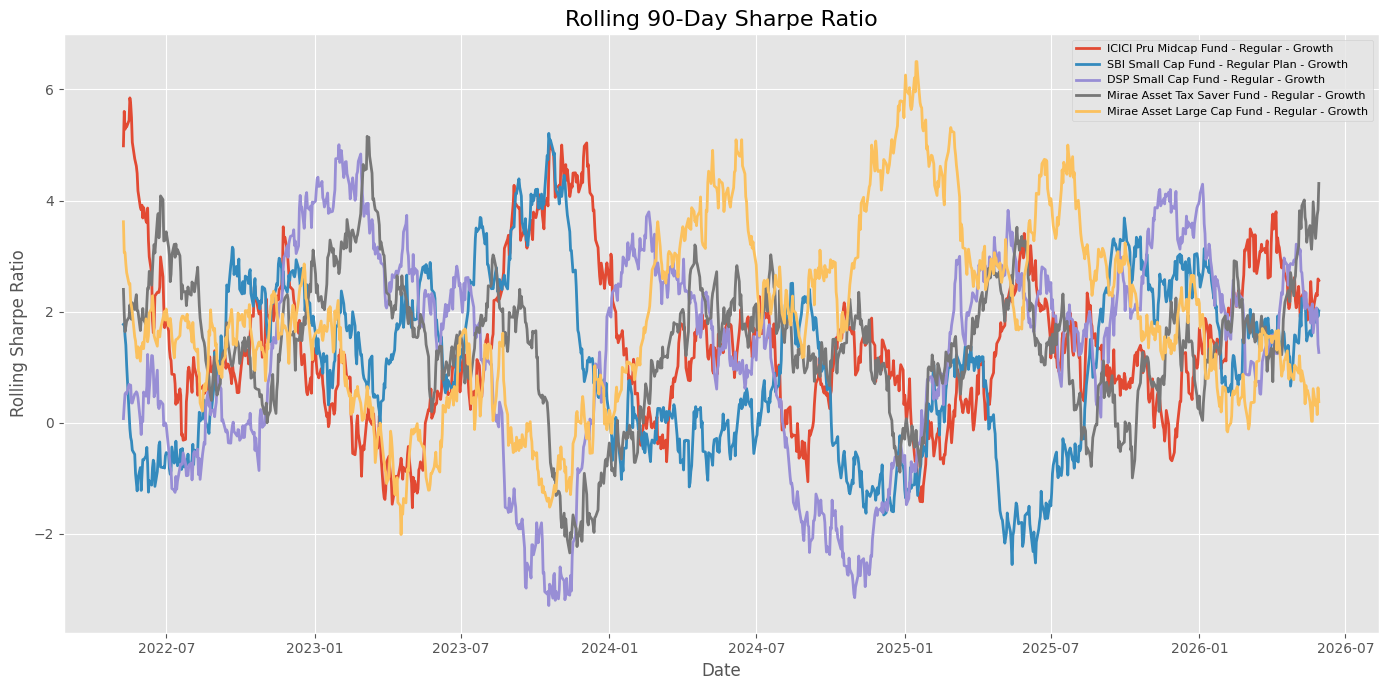

In [23]:
plt.figure(figsize=(14,7))

for fund in top5_funds:

    temp = rolling_data[
        rolling_data["scheme_name"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["Rolling Sharpe"],
        label=fund,
        linewidth=2
    )

plt.title("Rolling 90-Day Sharpe Ratio", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Rolling Sharpe Ratio")

plt.legend(fontsize=8)

plt.grid(True)

plt.tight_layout()

plt.show()

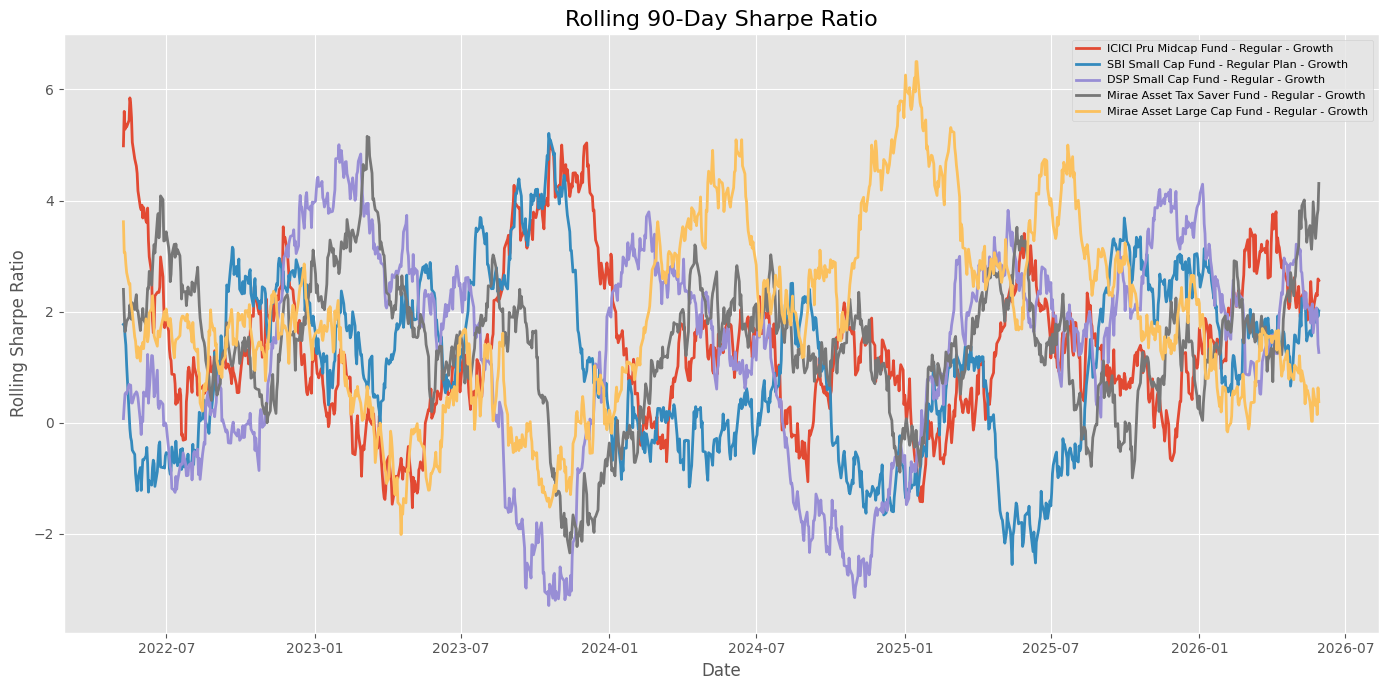

In [24]:
plt.figure(figsize=(14,7))

for fund in top5_funds:

    temp = rolling_data[
        rolling_data["scheme_name"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["Rolling Sharpe"],
        label=fund,
        linewidth=2
    )

plt.title("Rolling 90-Day Sharpe Ratio", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Rolling Sharpe Ratio")

plt.legend(fontsize=8)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
rolling_data.groupby("scheme_name")["Rolling Sharpe"].describe()

,count,mean,std,min,25%,50%,75%,max
scheme_name,,,,,,,,
DSP Small Cap Fund - Regular - Growth,1060.0,1.243431,1.923459,-3.296079,-0.052059,1.663474,2.675756,5.005512
ICICI Pru Midcap Fund - Regular - Growth,1060.0,1.386452,1.365359,-1.533714,0.505798,1.201339,2.147885,5.848667
Mirae Asset Large Cap Fund - Regular - Growth,1060.0,1.890422,1.655802,-2.017835,0.740275,1.727258,2.872815,6.503566
Mirae Asset Tax Saver Fund - Regular - Growth,1060.0,1.417243,1.228450,-2.348860,0.801833,1.485101,2.151434,5.156533
SBI Small Cap Fund - Regular Plan - Growth,1060.0,1.009269,1.551877,-2.558369,-0.310046,1.056049,2.253442,5.209215


Task 3 – Investor Cohort Analysis.

In [26]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [27]:
transactions["transaction_year"] = (
    transactions["transaction_date"].dt.year
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [28]:
cohort = (

    transactions

    .groupby("investor_id")["transaction_year"]

    .min()

    .reset_index()

)

cohort.columns = [
    "investor_id",
    "cohort_year"
]

cohort.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [29]:
transactions = transactions.merge(
    cohort,
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,2024


In [30]:
avg_sip = (

    transactions[
        transactions["transaction_type"]=="SIP"
    ]

    .groupby("cohort_year")["amount_inr"]

    .mean()

    .reset_index()

)

avg_sip.columns = [
    "cohort_year",
    "Average SIP"
]

avg_sip

,cohort_year,Average SIP
0,2024,10996.885825
1,2025,13505.209581


In [31]:
total_investment = (

    transactions

    .groupby("cohort_year")["amount_inr"]

    .sum()

    .reset_index()

)

total_investment.columns = [
    "cohort_year",
    "Total Investment"
]

total_investment

,cohort_year,Total Investment
0,2024,3491125187
1,2025,30455243


In [32]:
transactions = transactions.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

In [33]:
fund_pref = (

    transactions

    .groupby(
        [
            "cohort_year",
            "scheme_name"
        ]
    )

    .size()

    .reset_index(name="Count")

)

In [34]:
top_fund = (

    fund_pref

    .sort_values(
        ["cohort_year","Count"],
        ascending=[True,False]
    )

    .drop_duplicates("cohort_year")

)

top_fund = top_fund[
    [
        "cohort_year",
        "scheme_name"
    ]
]

top_fund.columns = [
    "cohort_year",
    "Top Fund"
]

top_fund

,cohort_year,Top Fund
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...
57,2025,ICICI Pru Liquid Fund - Regular - Growth


In [35]:
cohort_report = (

    avg_sip

    .merge(
        total_investment,
        on="cohort_year"
    )

    .merge(
        top_fund,
        on="cohort_year"
    )

)

cohort_report

,cohort_year,Average SIP,Total Investment,Top Fund
0,2024,10996.885825,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,30455243,ICICI Pru Liquid Fund - Regular - Growth


In [36]:
cohort_report.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

In [37]:
print("Number of Cohorts :", len(cohort_report))

cohort_report

Number of Cohorts : 2


,cohort_year,Average SIP,Total Investment,Top Fund
0,2024,10996.885825,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,30455243,ICICI Pru Liquid Fund - Regular - Growth


Task 4 — SIP Continuity Analysis

In [38]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year,scheme_name
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024,Axis Bluechip Fund - Regular - Growth
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,2024,Nippon India Small Cap Fund - Regular - Growth
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024,2024,ABSL Liquid Fund - Regular - Growth
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024,2024,ABSL Liquid Fund - Regular - Growth


In [40]:
sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year,scheme_name,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,2024,ICICI Pru Midcap Fund - Regular - Growth,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025,2024,HDFC Top 100 Fund - Direct Plan - Growth,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024,DSP Top 100 Equity Fund - Regular - Growth,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024,Kotak Bluechip Fund - Regular - Growth,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2025,2024,Axis Midcap Fund - Regular - Growth,238.0


In [41]:
sip_transactions["gap_days"] = (

    sip_transactions

    .groupby("investor_id")["transaction_date"]

    .diff()

    .dt.days

)

sip_transactions.head(15)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year,scheme_name,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,2024,ICICI Pru Midcap Fund - Regular - Growth,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025,2024,HDFC Top 100 Fund - Direct Plan - Growth,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024,DSP Top 100 Equity Fund - Regular - Growth,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024,Kotak Bluechip Fund - Regular - Growth,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2025,2024,Axis Midcap Fund - Regular - Growth,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,2024,ABSL Small Cap Fund - Regular - Growth,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2025,2024,DSP Top 100 Equity Fund - Regular - Growth,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,2024,ABSL Liquid Fund - Regular - Growth,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,2024,Axis Small Cap Fund - Regular - Growth,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,2024,Kotak Liquid Fund - Regular - Growth,28.0


In [42]:
sip_count = (

    sip_transactions

    .groupby("investor_id")

    .size()

    .reset_index(name="SIP Count")

)

sip_count.head()

,investor_id,SIP Count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [43]:
eligible_investors = sip_count[
    sip_count["SIP Count"] >= 6
]

eligible_investors.head()

,investor_id,SIP Count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [44]:
avg_gap = (

    sip_transactions

    .groupby("investor_id")["gap_days"]

    .mean()

    .reset_index()

)

avg_gap.columns = [
    "investor_id",
    "Average Gap (Days)"
]

avg_gap.head()

,investor_id,Average Gap (Days)
0,INV000001,76.0
1,INV000002,207.0
2,INV000003,238.0
3,INV000004,85.4
4,INV000005,14.0


In [45]:
sip_continuity = (

    eligible_investors

    .merge(
        avg_gap,
        on="investor_id"
    )

)

sip_continuity.head()

,investor_id,SIP Count,Average Gap (Days)
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000


In [46]:
sip_continuity["Status"] = sip_continuity[
    "Average Gap (Days)"
].apply(

    lambda x:
    "At Risk"
    if x > 35
    else "Healthy"

)

sip_continuity.head()

,investor_id,SIP Count,Average Gap (Days),Status
0,INV000004,6,85.400000,At Risk
1,INV000008,6,70.400000,At Risk
2,INV000010,6,64.800000,At Risk
3,INV000011,7,40.166667,At Risk
4,INV000012,8,57.000000,At Risk


In [47]:
sip_continuity["Status"].value_counts()

Status
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [48]:
sip_continuity.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

In [49]:
print("Eligible Investors :", len(sip_continuity))

print("\nAverage Gap")

print(
    sip_continuity["Average Gap (Days)"].describe()
)

sip_continuity.head(10)

Eligible Investors : 1362

Average Gap
count    1362.000000
mean       64.889132
std        15.593199
min        19.800000
25%        53.635417
50%        64.690476
75%        75.575000
max       102.600000
Name: Average Gap (Days), dtype: float64


,investor_id,SIP Count,Average Gap (Days),Status
0,INV000004,6,85.400000,At Risk
1,INV000008,6,70.400000,At Risk
2,INV000010,6,64.800000,At Risk
3,INV000011,7,40.166667,At Risk
4,INV000012,8,57.000000,At Risk
5,INV000013,7,55.333333,At Risk
6,INV000014,7,75.333333,At Risk
7,INV000023,8,58.571429,At Risk
8,INV000028,6,93.600000,At Risk
9,INV000029,7,60.666667,At Risk


Task 5 — Simple Fund Recommender

In [51]:
performance = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [52]:
performance.shape

(40, 19)

In [53]:
recommendation_df = performance.merge(

    fund_master[
        [
            "amfi_code",
            "risk_category"
        ]
    ],

    on="amfi_code",

    how="left"

)

recommendation_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,risk_category
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,Low


In [54]:
recommendation_df = recommendation_df[
    [
        "scheme_name",
        "risk_category",
        "sharpe_ratio",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
]

recommendation_df.head()

,scheme_name,risk_category,sharpe_ratio,return_3yr_pct,expense_ratio_pct
0,SBI Bluechip Fund - Regular Plan - Growth,Moderate,0.88,12.36,1.54
1,SBI Bluechip Fund - Direct Plan - Growth,Moderate,0.81,11.30,0.66
2,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94,23.39,1.43
3,SBI Small Cap Fund - Direct Plan - Growth,Very High,0.93,23.14,0.72
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,1.52,6.07,0.77


In [55]:
def recommend_funds(risk):

    result = (

        recommendation_df[
            recommendation_df["risk_category"]
            .str.lower()
            ==
            risk.lower()
        ]

        .sort_values(
            "sharpe_ratio",
            ascending=False
        )

        .head(3)

    )

    return result

In [56]:
recommend_funds("Moderate")

,scheme_name,risk_category,sharpe_ratio,return_3yr_pct,expense_ratio_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06,14.84,1.55
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06,14.81,1.46
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03,14.41,0.80


In [57]:
recommend_funds("Very High")

,scheme_name,risk_category,sharpe_ratio,return_3yr_pct,expense_ratio_pct
2,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94,23.39,1.43
3,SBI Small Cap Fund - Direct Plan - Growth,Very High,0.93,23.14,0.72
29,ABSL Small Cap Fund - Regular - Growth,Very High,0.90,22.38,1.53


In [58]:
recommend_funds("Low")

,scheme_name,risk_category,sharpe_ratio,return_3yr_pct,expense_ratio_pct
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68,7.68,0.74
23,Kotak Liquid Fund - Regular - Growth,Low,6.18,6.18,0.60
30,ABSL Liquid Fund - Regular - Growth,Low,5.14,5.14,0.79


Task 6 – Sector HHI (Herfindahl-Hirschman Index) Concentration.

In [59]:
holdings_hhi = holdings.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],

    on="amfi_code",

    how="left"

)

holdings_hhi.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,scheme_name,category
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Equity
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Equity
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Equity
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Equity
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Equity


In [60]:
equity_holdings = holdings_hhi[
    holdings_hhi["category"] == "Equity"
].copy()

equity_holdings.shape

(322, 10)

In [61]:
equity_holdings["weight_decimal"] = (
    equity_holdings["weight_pct"] / 100
)

equity_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,scheme_name,category,weight_decimal
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.1025


In [62]:
hhi_report = (

    equity_holdings

    .groupby("scheme_name")["weight_decimal"]

    .apply(
        lambda x: (x ** 2).sum()
    )

    .reset_index()

)

hhi_report.columns = [
    "scheme_name",
    "HHI"
]

hhi_report.head()

,scheme_name,HHI
0,ABSL Frontline Equity Fund - Regular - Growth,0.129332
1,ABSL Small Cap Fund - Regular - Growth,0.200700
2,Axis Bluechip Fund - Direct - Growth,0.130894
3,Axis Bluechip Fund - Regular - Growth,0.206448
4,Axis Midcap Fund - Regular - Growth,0.136406


In [63]:
def classify_hhi(hhi):

    if hhi < 0.10:
        return "Highly Diversified"

    elif hhi < 0.18:
        return "Moderately Concentrated"

    else:
        return "Highly Concentrated"


hhi_report["Portfolio Type"] = (
    hhi_report["HHI"]
    .apply(classify_hhi)
)

hhi_report.head()

,scheme_name,HHI,Portfolio Type
0,ABSL Frontline Equity Fund - Regular - Growth,0.129332,Moderately Concentrated
1,ABSL Small Cap Fund - Regular - Growth,0.200700,Highly Concentrated
2,Axis Bluechip Fund - Direct - Growth,0.130894,Moderately Concentrated
3,Axis Bluechip Fund - Regular - Growth,0.206448,Highly Concentrated
4,Axis Midcap Fund - Regular - Growth,0.136406,Moderately Concentrated


In [64]:
hhi_report = hhi_report.sort_values(
    "HHI",
    ascending=False
)

hhi_report.head(10)

,scheme_name,HHI,Portfolio Type
3,Axis Bluechip Fund - Regular - Growth,0.206448,Highly Concentrated
1,ABSL Small Cap Fund - Regular - Growth,0.200700,Highly Concentrated
29,SBI Small Cap Fund - Direct Plan - Growth,0.174751,Moderately Concentrated
33,UTI Nifty 50 Index Fund - Regular - Growth,0.174709,Moderately Concentrated
25,Nippon India Large Cap Fund - Regular - Growth,0.168298,Moderately Concentrated
20,Mirae Asset Emerging Bluechip Fund - Regular -...,0.167930,Moderately Concentrated
15,ICICI Pru Midcap Fund - Regular - Growth,0.157570,Moderately Concentrated
16,ICICI Pru Value Discovery Fund - Regular - Growth,0.153794,Moderately Concentrated
9,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.152414,Moderately Concentrated
17,Kotak Bluechip Fund - Regular - Growth,0.149680,Moderately Concentrated


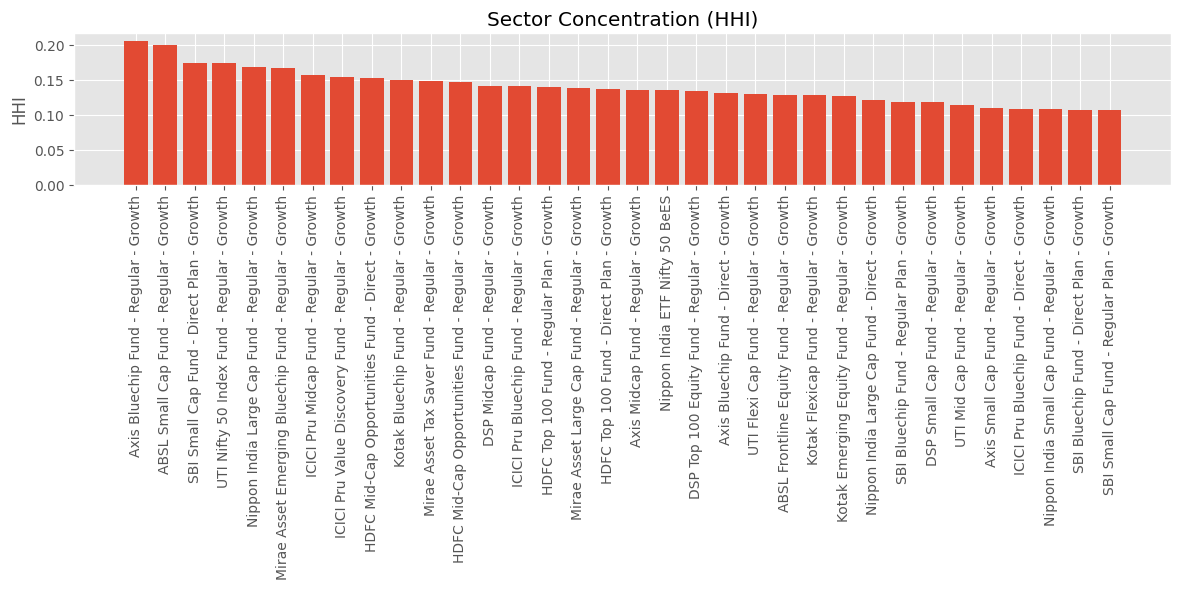

In [65]:
plt.figure(figsize=(12,6))

plt.bar(

    hhi_report["scheme_name"],

    hhi_report["HHI"]

)

plt.xticks(rotation=90)

plt.ylabel("HHI")

plt.title("Sector Concentration (HHI)")

plt.tight_layout()

plt.show()

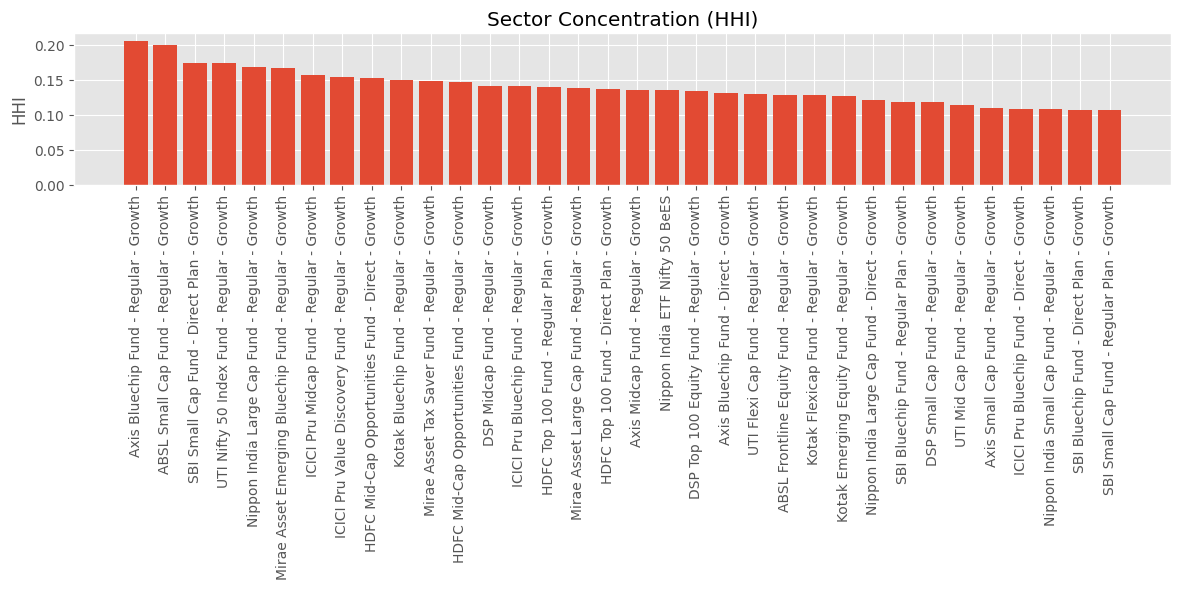

In [66]:
plt.figure(figsize=(12,6))

plt.bar(

    hhi_report["scheme_name"],

    hhi_report["HHI"]

)

plt.xticks(rotation=90)

plt.ylabel("HHI")

plt.title("Sector Concentration (HHI)")

plt.tight_layout()

plt.savefig(

    "../reports/hhi_concentration.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [67]:
hhi_report.to_csv(

    "../reports/hhi_report.csv",

    index=False

)

In [68]:
print("Total Equity Funds :", len(hhi_report))

print("\nPortfolio Types")

print(

    hhi_report["Portfolio Type"]

    .value_counts()

)

hhi_report.head(10)

Total Equity Funds : 34

Portfolio Types
Portfolio Type
Moderately Concentrated    32
Highly Concentrated         2
Name: count, dtype: int64


,scheme_name,HHI,Portfolio Type
3,Axis Bluechip Fund - Regular - Growth,0.206448,Highly Concentrated
1,ABSL Small Cap Fund - Regular - Growth,0.200700,Highly Concentrated
29,SBI Small Cap Fund - Direct Plan - Growth,0.174751,Moderately Concentrated
33,UTI Nifty 50 Index Fund - Regular - Growth,0.174709,Moderately Concentrated
25,Nippon India Large Cap Fund - Regular - Growth,0.168298,Moderately Concentrated
20,Mirae Asset Emerging Bluechip Fund - Regular -...,0.167930,Moderately Concentrated
15,ICICI Pru Midcap Fund - Regular - Growth,0.157570,Moderately Concentrated
16,ICICI Pru Value Discovery Fund - Regular - Growth,0.153794,Moderately Concentrated
9,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.152414,Moderately Concentrated
17,Kotak Bluechip Fund - Regular - Growth,0.149680,Moderately Concentrated


5 Advanced Insights

# Advanced Insights

## 1. Value at Risk (VaR)

Small-cap funds showed the highest downside risk at the 95% confidence level.
SBI Small Cap Fund and Axis Small Cap Fund recorded the most negative VaR and CVaR values, indicating higher potential losses during adverse market conditions.

---

## 2. Rolling Sharpe Ratio

Large-cap and diversified equity funds maintained relatively stable rolling Sharpe ratios over time.
Small-cap funds experienced larger fluctuations, reflecting higher volatility.

---

## 3. Investor Cohort Analysis

The 2024 investor cohort contributed the highest total investment amount and represented the largest share of SIP investors.
Newer investor cohorts invested smaller overall amounts but maintained higher average SIP values.

---

## 4. SIP Continuity Analysis

Among investors having six or more SIP transactions, the majority were classified as "At Risk" because the average gap between SIP payments exceeded 35 days.
This suggests a significant opportunity for improving SIP retention.

---

## 5. Portfolio Concentration

Only two equity funds were classified as Highly Concentrated based on the Herfindahl-Hirschman Index (HHI).
Most equity funds maintained diversified sector allocations, indicating balanced portfolio construction.